# Pandas Reconciliation

Independently re-implementing the SQL pipeline (`sql/01-clean.sql` through
`sql/03-channel.sql`) in pandas, then reconciling the two with
`assert_frame_equal`. Two independent implementations agreeing is the
standard way to trust a metric — if either had a bug, they'd very likely
disagree on something.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)


## Step 1 — Three-step cleaning in pandas

Independent from the SQL implementation — reads the raw CSV directly,
does not touch anything the SQL side produced.

In [2]:
raw = pd.read_csv('../data/youtube.csv')
raw['trend_dt'] = pd.to_datetime(raw['trending_date'], format='%y.%d.%m')

pub_attrs = raw[raw['video_id'] != '#NAME?'].groupby('video_id').agg(
    n_pub=('publish_date', 'nunique'), n_tf=('time_frame', 'nunique'))
bad_pub = pub_attrs[(pub_attrs.n_pub > 1) | (pub_attrs.n_tf > 1)].index

clean_py = (
    raw[(raw['video_id'] != '#NAME?') & (~raw['video_id'].isin(bad_pub))]
      .sort_values(['views', 'likes'], ascending=False)
      .drop_duplicates(subset=['video_id', 'publish_country', 'trend_dt'], keep='first')
)
print(f'clean_py rows: {len(clean_py)} (expected 159,377)')
assert len(clean_py) == 159_377


clean_py rows: 159377 (expected 159,377)


## Step 2 — Video-level table in pandas

`sort_values('trend_dt')` then `.last()` in the aggregation is how pandas
achieves what SQL's `ARG_MAX(col, trend_dt)` does — pandas has no built-in
`ARG_MAX`, so sorting ascending by the tie-break column first, then taking
the last row per group, gives the same latest-snapshot value.

In [3]:
video_life_py = (
    clean_py.sort_values('trend_dt')
         .groupby(['video_id', 'publish_country'])
         .agg(channel_title=('channel_title', 'last'),
              category_id=('category_id', 'last'),
              days_on_trending=('trend_dt', 'nunique'),
              first_trend_day=('trend_dt', 'min'),
              last_trend_day=('trend_dt', 'max'),
              peak_views=('views', 'max'),
              peak_likes=('likes', 'max'),
              peak_comments=('comment_count', 'max'))
         .reset_index()
)
video_life_py['trending_span'] = (
    video_life_py['last_trend_day'] - video_life_py['first_trend_day']
).dt.days + 1
video_life_py['survived_day1'] = (video_life_py['days_on_trending'] >= 2).astype(int)

print(f'video_life_py rows: {len(video_life_py)} (expected 63,783)')
assert len(video_life_py) == 63_783


video_life_py rows: 63783 (expected 63,783)


## Step 3 — Reconciliation against the SQL side

Load the SQL-built `video_life.csv` (exported by `src/build_tables.py`),
project onto the columns pandas actually has (SQL's version has extra
columns like `gap_real`/`gap_scrape`, `pub_dow`, `pub_hour_utc` that this
pandas pass didn't compute — comparing mismatched columns would fail on
a column-set error unrelated to whether the numbers agree), sort both by
the same key, reset the index, then assert equality.

In [4]:
video_life_sql = pd.read_csv('../data/exports/video_life.csv', parse_dates=['first_trend_day', 'last_trend_day'])

keys = ['video_id', 'publish_country']
common_cols = [c for c in video_life_py.columns]

left = video_life_py.sort_values(keys).reset_index(drop=True)
right = video_life_sql[common_cols].sort_values(keys).reset_index(drop=True)

pd.testing.assert_frame_equal(left, right, check_dtype=False)
print('Reconciliation PASSED: pandas and SQL implementations agree on all', len(common_cols), 'shared columns.')


Reconciliation PASSED: pandas and SQL implementations agree on all 12 shared columns.


## Four charts, each answering one question

Titles are the question, subtitles are the answer.

### Chart 1 — How long do videos survive after trending? (faceted by country)

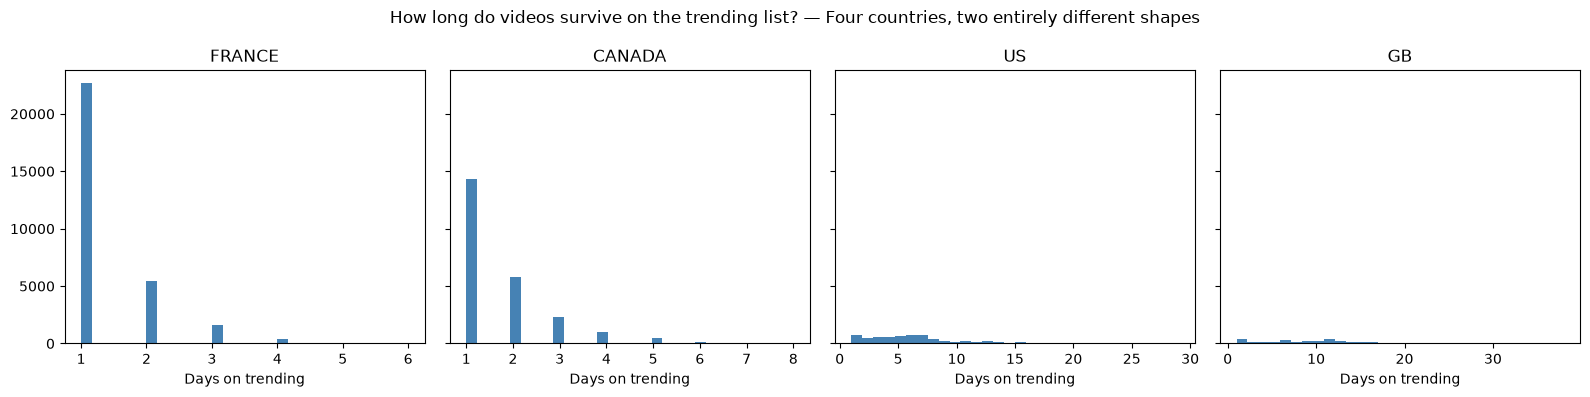

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
countries = ['FRANCE', 'CANADA', 'US', 'GB']
for ax, country in zip(axes, countries):
    subset = video_life_sql[video_life_sql['publish_country'] == country]
    ax.hist(subset['days_on_trending'], bins=30, color='steelblue')
    ax.set_title(country)
    ax.set_xlabel('Days on trending')
fig.suptitle('How long do videos survive on the trending list? — Four countries, two entirely different shapes')
plt.tight_layout()
plt.savefig('../figures/01_days_distribution.png', dpi=150)
plt.show()


### Chart 2 — How does a video's popularity decay after trending?

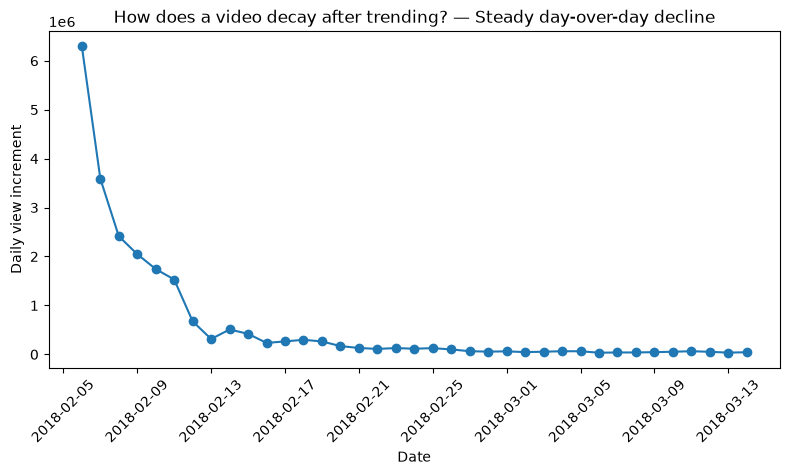

In [6]:
video_data = clean_py[(clean_py['video_id'] == 'NooW_RbfdWI') & (clean_py['publish_country'] == 'GB')].sort_values('trend_dt')
video_data = video_data.copy()
video_data['views_gained'] = video_data['views'].diff().clip(lower=0)

plt.figure(figsize=(8, 5))
plt.plot(video_data['trend_dt'], video_data['views_gained'], marker='o')
plt.title('How does a video decay after trending? — Steady day-over-day decline')
plt.xlabel('Date')
plt.ylabel('Daily view increment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../figures/02_decay_curve.png', dpi=150)
plt.show()


### Chart 3 — Does Friday publishing really help? (by country)

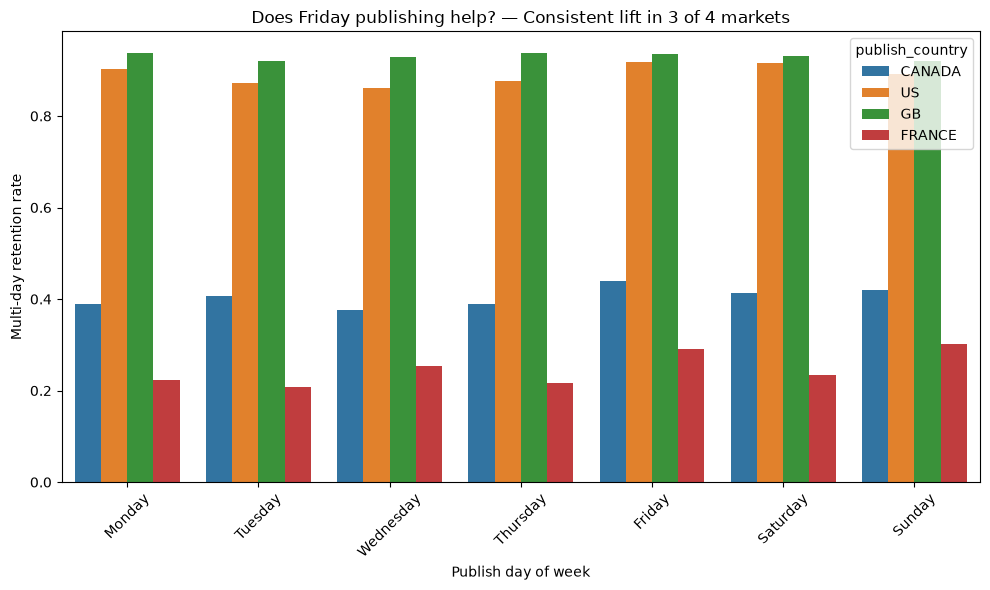

In [7]:
pivot = video_life_sql.groupby(['publish_country', 'pub_dow'])['survived_day1'].mean().reset_index()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot['pub_dow'] = pd.Categorical(pivot['pub_dow'], categories=day_order, ordered=True)
pivot = pivot.sort_values('pub_dow')

plt.figure(figsize=(10, 6))
sns.barplot(data=pivot, x='pub_dow', y='survived_day1', hue='publish_country')
plt.title('Does Friday publishing help? — Consistent lift in 3 of 4 markets')
plt.ylabel('Multi-day retention rate')
plt.xlabel('Publish day of week')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../figures/03_dow_retention.png', dpi=150)
plt.show()


### Chart 4 — Do the most frequently-trending channels also have the longest-lived videos?

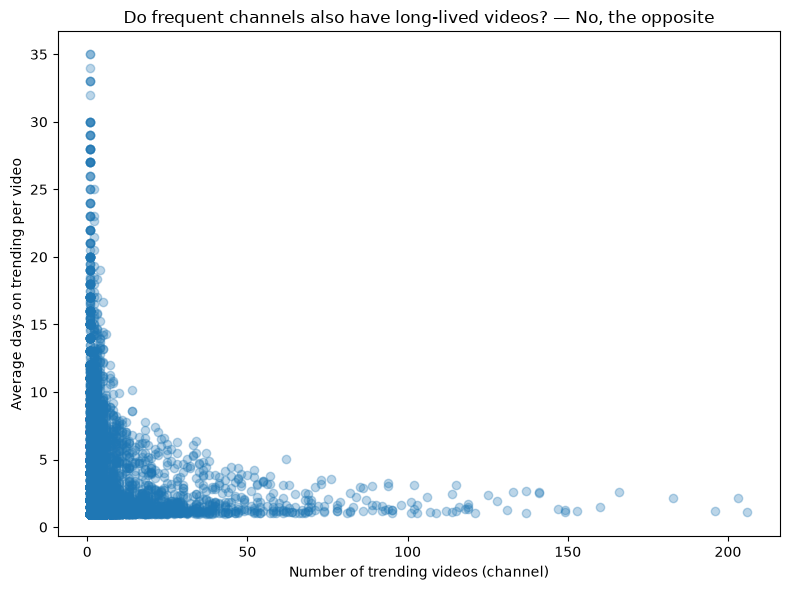

In [8]:
channel_sql = pd.read_csv('../data/exports/channel.csv')

plt.figure(figsize=(8, 6))
plt.scatter(channel_sql['trending_videos'], channel_sql['avg_video_life'], alpha=0.3)
plt.title('Do frequent channels also have long-lived videos? — No, the opposite')
plt.xlabel('Number of trending videos (channel)')
plt.ylabel('Average days on trending per video')
plt.tight_layout()
plt.savefig('../figures/04_channel_scatter.png', dpi=150)
plt.show()


**Conclusion**: the top 5 most-frequent channels (all daily-upload
institutional accounts) have some of the *shortest* average per-video
lifespans — they rely on publish volume, not per-video staying power.


In [9]:
channel_sql.sort_values('trending_videos', ascending=False).head(5)

,channel_title,trending_videos,avg_video_life,multi_day_rate,countries_reached
6185,VikatanTV,206,1.091483,0.088328,2
6059,The Late Show with Stephen Colbert,203,2.184300,0.344710,4
55,Elhiwar Ettounsi,196,1.178862,0.174797,2
111,ESPN,183,2.186916,0.425234,3
212,CNN,166,2.620321,0.486631,4
